# Model to transform infrastructure

- enables to transform the methane into a hydrogen network
- allows for new investments on defined edges
- bidirectional net flows on edges possible

### Import packages

In [154]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import networkx as nx
import os
from collections import Counter

In [155]:
# Define a function to convert the solution to a DataFrame
def solution_to_dataframe(commodities, edges, solution, String):
    # Create an empty list to store the data
    data = []
    
    # Iterate over commodities and edges to populate the data list
    for h in commodities:
        for i, j in edges:
            if solution[h, i, j] > 0:
                data.append({'Commodity': h, 'Source': i, 'Destination': j, String: solution[h, i, j]})
    
    # Convert the data list to a DataFrame
    df = pd.DataFrame(data)
    
    # Return the DataFrame
    return df

def conversion_solution_to_dataframe(commodities, edges, solution):
    # Create an empty list to store the data
    data = []
    
    # Iterate over commodities and edges to populate the data list
    for h in commodities:
        for i, j in edges:
            # Append the data to the list as a dictionary
            data.append({
                'Commodity': h,
                'Source': i,
                'Destination': j,
                'Conversion': solution[h, i, j]
            })
    
    # Convert the data list to a DataFrame
    df = pd.DataFrame(data)
    
    # Return the DataFrame
    return df

### Model run definitions

In [156]:
#use shortage nodes to avoid infeasibilities
model_with_shortage = False #True or False

# use excess nodes to avoid infeasibilities
model_with_excess = True #True or False

#should the code print the results in the notebook?
print_results = True #True or False

### Import data

In [157]:
# Specify the path to your Excel file
input_file_path = os.path.join('..', '..','01_data', '01_input_data', '02_processed')
excel_file_path = '\Data_full_network.xlsx'  
# excel_file_path = '\dummy_data_example_network.xlsx'

input_file_path  = input_file_path + excel_file_path
full_input_path = os.path.abspath(os.path.join(os.getcwd(), input_file_path))

output_file_path = os.path.join('..', '..', '01_data', '02_output_data', '01_bidirectional_results')
output_file_name = '\\flow_and_network_data.xlsx'
output_path_file =  output_file_path + output_file_name
full_output_path_file = os.path.abspath(os.path.join(os.getcwd(), output_path_file))

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
C:\Users\mar.eco\AppData\Local\Temp\ipykernel_13284\2343090348.py:3: SyntaxWarning: invalid escape sequence '\D'
  excel_file_path = '\Data_full_network.xlsx'


In [158]:
# Read the Excel file into a DataFrame
df_nodes = pd.read_excel(full_input_path, sheet_name='Nodes')
df_commodities = pd.read_excel(full_input_path, sheet_name='Commodities')
df_edges = pd.read_excel(full_input_path, sheet_name='Edges')
df_parameter = pd.read_excel(full_input_path, sheet_name='Parameters')
df_supply_values = pd.read_excel(full_input_path, sheet_name='Supply')

In [159]:
# Test model with new supply values 
df_supply_values.loc[(df_supply_values['Node'] == 'node_0010') & (df_supply_values['Commodity'] == 'Methane'), 'Supply'] = 5
df_supply_values.loc[(df_supply_values['Node'] == 'node_0020') & (df_supply_values['Commodity'] == 'Methane'), 'Supply'] = -3
df_supply_values.loc[(df_supply_values['Node'] == 'node_0030') & (df_supply_values['Commodity'] == 'Methane'), 'Supply'] = -2

### Create input data structure

In [160]:
#commodities
commodities = df_commodities['Commodities'].tolist()

#nodes
nodes = df_nodes['Nodes'].tolist()

#edges
edges_base = list(zip(df_edges['Source'], df_edges['Destination']))

#initial capacities
capacity_base = {tuple(row[['Commodity', 'Source', 'Destination']]): row['initial_capacities'] 
                 for _, row in df_parameter.iterrows()}

#maximal capacities
capacity_limit_base = {tuple(row[['Commodity', 'Source', 'Destination']]): row['max_capacities'] 
                 for _, row in df_parameter.iterrows()}

#variable transportation cost
cost_base = {tuple(row[['Commodity', 'Source', 'Destination']]): row['costs_edge'] 
                 for _, row in df_parameter.iterrows()}

#investment cost new capacity
investment_cost_base = {tuple(row[['Commodity', 'Source', 'Destination']]): row['new_build_cost'] 
                 for _, row in df_parameter.iterrows()}

#investment cost convert capacity
conversion_cost_base = {tuple(row[['Commodity', 'Source', 'Destination']]): row['conversion_cost'] 
                 for _, row in df_parameter.iterrows()}

#converseion capacity factor
conversion_capacity_factor = {tuple(row[['Commodity', 'Source', 'Destination']]): row['conversion_capacity_factor'] 
                 for _, row in df_parameter.iterrows()}

#demand and supply
inflow = {tuple(row[['Commodity', 'Node']]): row['Supply'] 
                 for _, row in df_supply_values.iterrows()}

### adjust input data

In [161]:
#create node types for different model configurations
if model_with_shortage == True:
    #create shortage nodes
    supply_nodes = []
    for (commodity, node), value in inflow.items():
        if value > 0:
            supply_nodes.append(node)
    unique_supply_nodes = list(set(supply_nodes))
    # Add '_shortage' to each element in the list
    unique_supply_nodes_shortage = [node + '_shortage' for node in unique_supply_nodes]
    nodes_shortage = unique_supply_nodes_shortage
    #create new edges for all shortage nodes to the actual node with high-capacity
    # Create a new list by zipping the two lists
    edges_shortage = list(zip(unique_supply_nodes_shortage, unique_supply_nodes))
    # Create a new data structure using the result_list and commodities
    edge_shortage_cap = {}

    for (commodity, suffix, original) in [(c, s, o) for c in commodities for s, o in zip(unique_supply_nodes_shortage, unique_supply_nodes)]:
        edge_shortage_cap[(commodity, suffix, original)] = 10000000

    nodes_network = nodes #+ nodes_shortage
else:
    nodes_network = nodes
    edges_shortage = []
    nodes_shortage = []

In [162]:
# excess nodes construction
if model_with_excess:
    # get the nodes that supply
    supply_nodes = [node for (_, node), val in inflow.items() if val > 0]
    unique_supply_nodes = list(set(supply_nodes))

    # create a twin called mode_excess 
    # nodes_excess = [f"{n}_excess" for n in unique_supply_nodes]

    # create for each nodes 
    nodes_excess = [f"{n}_excess" for n in nodes]

    # store a dumb edge but only for the nodes from unique supply
    edges_excess = list(zip(unique_supply_nodes, nodes_excess))

    # add everything to the global list
    nodes += nodes_excess
    edges_base += edges_excess


    # attribute huge capacity and dumping penalty --> check for model coherence 
    BIG_PENALTY  = 1000.0
    BIG_CAP      = 1e9       

    for c in commodities:
        for u, v in edges_excess:
            key = (c, u, v)
            capacity_base[key]         = BIG_CAP
            capacity_limit_base[key]   = BIG_CAP
            cost_base[key]             = BIG_PENALTY
            investment_cost_base[key]  = 0.0
            conversion_cost_base[key]  = 0.0
            conversion_capacity_factor[key] = 1.0

    # necessary zero inflow for the Kirshhoff cnstraint (otherwise does not work)
    for c in commodities:
        for v in nodes_excess:
            inflow[(c, v)] = 0.0
else:
    edges_excess  = []
    nodes_excess  = []

In [163]:
# Reverse edges
edges_reverse = [(destination, source) for source, destination in edges_base  if (source, destination) not in edges_excess] # do not take the excess nodes

# Combined edges
edges = edges_base + edges_reverse

# Reverse cap
capacity_reverse = {(k, j, i): cap for (k, i, j), cap in capacity_base.items()}

capacity = {**capacity_base, **capacity_reverse}

# Reverse cap
capacity_limit_reverse = {(k, j, i): cap for (k, i, j), cap in capacity_limit_base.items()}

capacity_limit = {**capacity_limit_base, **capacity_limit_reverse}

# Reverse cost
cost_reverse = {(k, j, i): cost for (k, i, j), cost in cost_base.items()}

cost = {**cost_base, **cost_reverse}

# Reverse cost
investment_cost_reverse = {(k, j, i): cost for (k, i, j), cost in investment_cost_base.items()}

investment_cost = {**investment_cost_base, **investment_cost_reverse}

# Reverse cost
conversion_cost_reverse = {(k, j, i): cost for (k, i, j), cost in conversion_cost_base.items()}

conversion_cost = {**conversion_cost_base, **conversion_cost_reverse}


### Network control

In [164]:
#check in all nodes are connected via edges

G = nx.Graph()
G.add_edges_from(edges_base)

# Check if the graph is connected
if nx.is_connected(G):
    print("The graph is connected.")
else:
    print("The graph is not connected.")

The graph is connected.


In [165]:
# Check if all nodes are connected
if set(nodes) in nx.connected_components(G):
    print("All nodes are connected.")
else:
    print("Not all nodes are connected.")

Not all nodes are connected.


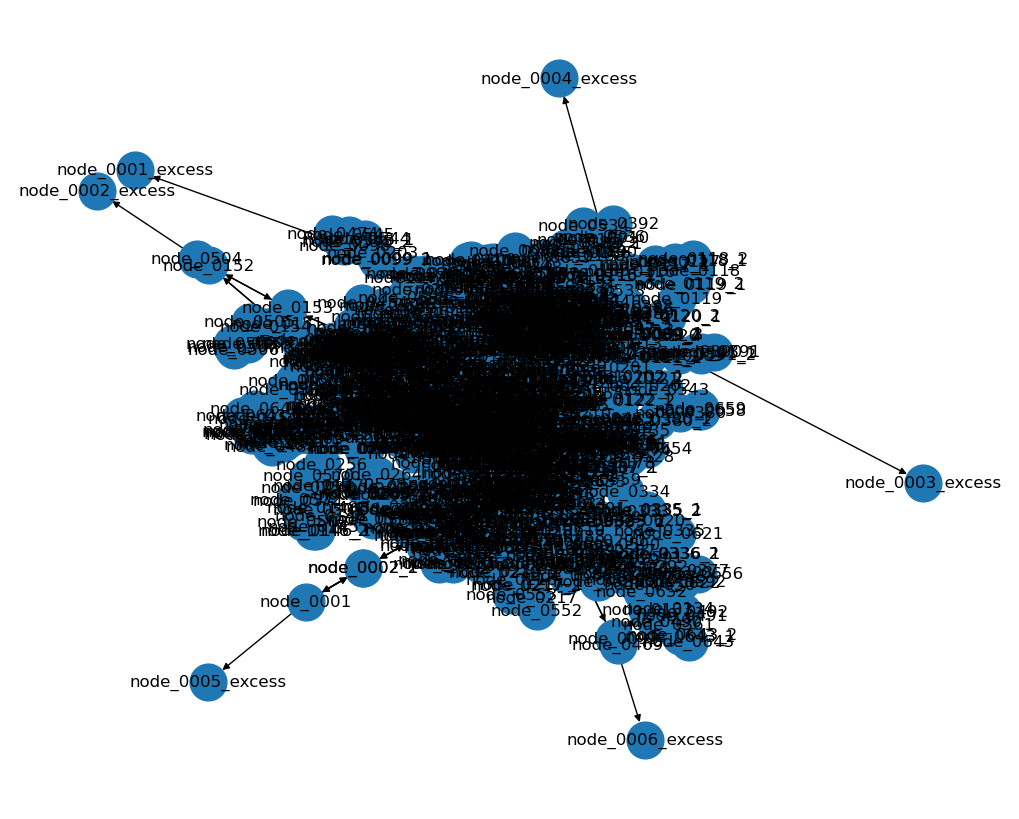

In [166]:
import matplotlib.pyplot as plt

G = nx.DiGraph()
for i, j in edges:  
    G.add_edge(i, j)

plt.figure(figsize=(10,8))
nx.draw(G, with_labels=True, node_size=700)
plt.show()


In [167]:
if len(edges) != len(set(edges)):
    print("There are duplicates in the list of tuples.")

    # Count occurrences of each edge
    edge_count = Counter(edges)

    # Find duplicates
    duplicates = [edge for edge, count in edge_count.items() if count > 1]
    #print duplicated edges if they exist
    for dup in duplicates:
        print(dup)
else:
    print("No duplicates found in the list of tuples.")

No duplicates found in the list of tuples.


## Model

### Create model

In [168]:
# Create optimization model
m = gp.Model("Grid_Transformation")

### Define variables

In [169]:
# defin two different edge sets accounting for every edge useful
edges_phys = edges_base                    # physical arcs
edges_phys_all = edges_phys + [(j, i) for (i, j) in edges_phys if (i, j) not in edges_excess]     # add reverse of physical arcs

# Flow travels everywhere
edges_flow = edges_phys_all + edges_excess

# But the ivestment and capacity are only on physical ones
edges_capital = edges_phys_all

# Avoid duplicates here as well 
edges = list(dict.fromkeys(edges))
edges_flow = list(dict.fromkeys(edges_flow))
edges_capital = list(dict.fromkeys(edges_capital))

In [170]:
# Create variables
edges_total = edges_flow + edges_shortage if model_with_shortage else edges_flow
edges_total = list(dict.fromkeys(edges_total))

flow = m.addVars(commodities, edges_total, vtype=GRB.CONTINUOUS, name="flow")

# Change edges to edges_capital to have physical ones only 
# variable for capacity investment
investment = m.addVars(commodities, edges_capital, vtype=GRB.CONTINUOUS, name="investment")

# Variable for converted capacity
converted_capacity = m.addVars(commodities, edges_capital, vtype=GRB.CONTINUOUS, name="converted_capacity")

# Binary variable to indicate if conversion is active
conversion_indicator = m.addVars(commodities, edges_capital, vtype=GRB.BINARY, name="conversion_indicator")

### Define objective

In [171]:
# Set objective function
m.setObjective(
    gp.quicksum(flow[h, i, j] * cost[h, i, j] for h in commodities for i, j in edges) +
    gp.quicksum(investment[h, i, j] * investment_cost[h, i, j] for h in commodities for i, j in edges_base) +
    gp.quicksum(converted_capacity[h, i, j] * conversion_cost[h, j, i] for h in commodities for i, j in edges_base),
    GRB.MINIMIZE
)

### Define constraints

In [172]:
# Edge-capacity constraints with investment
m.addConstrs((flow[h, i, j] <= converted_capacity[h, i, j] + investment[h, i, j] for h in commodities for i, j in edges_capital), "cap")

# Edge-capacity total limit
m.addConstrs((investment[h, i, j] + converted_capacity[h, i, j] 
              <= capacity_limit[h, i, j] for h in commodities for i, j in edges_base), "cap")

# Investment constraints
m.addConstrs((investment[h, i, j] == investment[h, j, i] for h in commodities for i, j in edges_capital if (j, i) in edges_capital), "conversion")

#conversion binary constraint
m.addConstrs((gp.quicksum(conversion_indicator[h, i, j] for h in commodities) == 1 for i, j in edges_capital), "conversion_indicator_sum_one")

#link the converted capacity to the initial capacity
m.addConstrs((capacity[commodities[0], i, j] * conversion_indicator[h, i, j] 
              == converted_capacity[h, i, j] for h in commodities[1:] for i, j in edges_capital), "capacity_relationship")
m.addConstrs((capacity[commodities[0], i, j] * conversion_indicator[commodities[0], i, j]
        == converted_capacity[commodities[0], i, j]
        for i, j in edges_capital), "capacity_relationship_first_commodity")

# Conversion constraints
m.addConstrs((converted_capacity[h, i, j] == converted_capacity[h, j, i] for h in commodities for i, j in edges_capital if (j, i) in edges_capital), "conversion")

# balanced node flows: Kirchhoff's 1st law
m.addConstrs(
    (
        flow.sum(h, "*", j) + inflow[h, j] == flow.sum(h, j, "*")
        for h in commodities
        for j in nodes_network
    ),
    "node",
)

# Flow-conservation constraints
if model_with_shortage == True: 
    m.addConstrs(
        (
            flow.sum(h, "*", j) - flow.sum(h, j, "*") <= 0
            for h in commodities
            for j in nodes_shortage
        ),
        "node",
    )

    # Edge-capacity constraints between shortage nodes and network nodes
    m.addConstrs((flow[h, i, j] <= edge_shortage_cap[h, i, j] for h in commodities for i, j in edges_shortage), "cap")

print('Constraints createt')

Constraints createt


In [173]:
# Checking code 
print("Flow edges:", len(edges_flow))
print("Capital investment edges:", len(edges_capital))
print("Shortage edges:", len(edges_shortage) if model_with_shortage else 0)

Flow edges: 2664
Capital investment edges: 2664
Shortage edges: 0


### Optimize the model

In [174]:
# Compute optimal solution
m.optimize()

Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (22631.2))

CPU model: AMD Ryzen 5 PRO 3500U w/ Radeon Vega Mobile Gfx, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 30494 rows, 21312 columns and 69228 nonzeros
Model fingerprint: 0x30f4c70d
Variable types: 15984 continuous, 5328 integer (5328 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+09]
  Objective range  [5e-01, 1e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 26946 rows and 16847 columns
Presolve time: 0.18s
Presolved: 3548 rows, 4465 columns, 13262 nonzeros
Variable types: 3829 continuous, 636 integer (636 binary)
Found heuristic solution: objective 1731.5477158

Root relaxation: objective 9.503878e+02, 553 iterations, 0.03 seconds (0.01 work units)

    Nod

In [175]:
for constr in m.getConstrs():
    name = constr.ConstrName
    if name.startswith("node["):
        rhs = constr.RHS
        if rhs < 0:
            print(f"{name} → {rhs}")
        elif rhs > 0:
            print(f"{name} → {rhs}")
        else:
            print(f"{name} → 0")

node[Methane,node_0001] → -5.0
node[Methane,node_0002] → 0
node[Methane,node_0003] → 0
node[Methane,node_0004] → 0
node[Methane,node_0005] → 0
node[Methane,node_0006] → 0
node[Methane,node_0007] → 0
node[Methane,node_0008] → 0
node[Methane,node_0009] → -5.0
node[Methane,node_0010] → -5.0
node[Methane,node_0011] → 0
node[Methane,node_0012] → 0
node[Methane,node_0013] → 0
node[Methane,node_0014] → 0
node[Methane,node_0015] → 0
node[Methane,node_0016] → 0
node[Methane,node_0017] → 0
node[Methane,node_0018] → 0
node[Methane,node_0019] → 0
node[Methane,node_0020] → 3.0
node[Methane,node_0021] → 0
node[Methane,node_0022] → 0
node[Methane,node_0023] → 0
node[Methane,node_0024] → 0
node[Methane,node_0025] → 0
node[Methane,node_0026] → 0
node[Methane,node_0027] → 0
node[Methane,node_0028] → 0
node[Methane,node_0029] → 0
node[Methane,node_0030] → 2.0
node[Methane,node_0031] → 0
node[Methane,node_0032] → 0
node[Methane,node_0033] → 0
node[Methane,node_0034] → 0
node[Methane,node_0035] → 0
node[Me

In [176]:
for c in commodities:
    for u, v in edges_excess:
        if flow[c, u, v].X > 1e-6:
            print(f"Excess used: {c} from {u} to {v} = {flow[c, u, v].X}")

In [177]:
''' 
# In case the model is infeasible  
m.computeIIS()

for c in m.getConstrs():
    if c.IISConstr:
        print(f"Infeasible cstr: {c.ConstrName} → rhs: {c.RHS}")

for v in m.getVars():
    if v.IISLB:
        print(f"Infeasible lower bound: {v.VarName} ≥ {v.LB}")
    if v.IISUB:
        print(f"Infeasible upper bound: {v.VarName} ≤ {v.UB}")'''

' \n# In case the model is infeasible  \nm.computeIIS()\n\nfor c in m.getConstrs():\n    if c.IISConstr:\n        print(f"Infeasible cstr: {c.ConstrName} → rhs: {c.RHS}")\n\nfor v in m.getVars():\n    if v.IISLB:\n        print(f"Infeasible lower bound: {v.VarName} ≥ {v.LB}")\n    if v.IISUB:\n        print(f"Infeasible upper bound: {v.VarName} ≤ {v.UB}")'

## Outputs

In [178]:
if m.Status == GRB.OPTIMAL:
    solution = m.getAttr("X", flow)
    investment_solution = m.getAttr("X", investment)
    converted_capacity_solution = m.getAttr("X", converted_capacity)
    conversion_indicator_solution = m.getAttr("X", conversion_indicator)

    print("****************************")
    print(f"Total cost: {m.objVal}")
    print("****************************")

    if print_results == True:
    
        for h in commodities:
            print(f"\nOptimal flows for {h}:")
            for i, j in edges:
                if solution[h, i, j] > 0:
                    print(f"{i} -> {j}: {solution[h, i, j]:g}")
    
            if model_with_shortage == True:
                for i, j in edges_shortage:
                    if solution[h, i, j] > 0:
                        print(f"{i} -> {j}: {solution[h, i, j]:g}")
    
            print(f"\nOptimal investments for {h}:")
            for i, j in edges_base:
                if investment_solution[h, i, j] > 0:
                    print(f"Investment for {h} in edge ({i} -> {j}): {investment_solution[h, i, j]:g}")
    
            print(f"\nOptimal converted capacities for {h}:")
            for i, j in edges_base:
                if converted_capacity_solution[h, i, j] > 0:
                    print(f"Converted capacity for {h} from {i} to {j}: {converted_capacity_solution[h, i, j]:g}")
    
        print("\nOptimal conversion indicators:")
        for h in commodities:
            for i, j in edges_base:
                #
                    print(f"Conversion of {h} from {i} to {j} is: {conversion_indicator_solution[h, i, j]:g}")
else:
    print("No optimal solution found.")

****************************
Total cost: 1133.6855508291328
****************************

Optimal flows for Methane:
node_0001 -> node_0002_2: 5
node_0002 -> node_0362: 5
node_0009 -> node_0012: 10
node_0011 -> node_0096: 5
node_0012 -> node_0020: 3
node_0012 -> node_0021: 7
node_0021 -> node_0033: 7
node_0031 -> node_0411: 5
node_0033 -> node_0035: 7
node_0043 -> node_0069: 10
node_0049 -> node_0429_1: 5
node_0061 -> node_0215: 5
node_0068 -> node_0070: 10
node_0070 -> node_0071: 10
node_0071 -> node_0072: 10
node_0072 -> node_0073: 5
node_0072 -> node_0451: 5
node_0073 -> node_0074: 5
node_0074 -> node_0452: 5
node_0092 -> node_0110_1: 5
node_0136 -> node_0208: 5
node_0137 -> node_0212: 5
node_0151 -> node_0156: 1.14796
node_0152 -> node_0153: 3.85204
node_0153 -> node_0158: 3.85204
node_0156 -> node_0157_1: 1.14796
node_0157 -> node_0158: 1.14796
node_0158 -> node_0159: 5
node_0159 -> node_0160: 5
node_0160 -> node_0296: 4.9769
node_0160 -> node_0297: 0.0231028
node_0215 -> node_036

In [179]:
costs_df = pd.DataFrame({'Total Cost': [m.objVal]})
flows_df = solution_to_dataframe(commodities, edges, solution, 'Flow')
if model_with_shortage == True:
    flows_shortage_df = solution_to_dataframe(commodities, edges_shortage, solution, 'Flow')
investments_df = solution_to_dataframe(commodities, edges_base, investment_solution, 'Capacity_invested')
conversion_df = solution_to_dataframe(commodities, edges_base, converted_capacity_solution, 'Capacity_converted')
conversion_binaries_df = conversion_solution_to_dataframe(commodities, edges_base, conversion_indicator_solution)

In [180]:
'''#create the ouput excel 
with pd.ExcelWriter(full_output_path_file) as writer:
    costs_df.to_excel(writer, sheet_name='network_costs', index=False) 
    flows_df.to_excel(writer, sheet_name='network_flows', index=False)
    if model_with_shortage == True:
            flows_shortage_df.to_excel(writer, sheet_name='network_shortage_flows', index=False)
    investments_df.to_excel(writer, sheet_name='Investment', index=False)
    conversion_df.to_excel(writer, sheet_name='Conversion', index=False)
    conversion_binaries_df.to_excel(writer, sheet_name='Conversion_binaries', index=False)
'''

"#create the ouput excel \nwith pd.ExcelWriter(full_output_path_file) as writer:\n    costs_df.to_excel(writer, sheet_name='network_costs', index=False) \n    flows_df.to_excel(writer, sheet_name='network_flows', index=False)\n    if model_with_shortage == True:\n            flows_shortage_df.to_excel(writer, sheet_name='network_shortage_flows', index=False)\n    investments_df.to_excel(writer, sheet_name='Investment', index=False)\n    conversion_df.to_excel(writer, sheet_name='Conversion', index=False)\n    conversion_binaries_df.to_excel(writer, sheet_name='Conversion_binaries', index=False)\n"